# YOLOv8 Training on MOCS Dataset

This notebook demonstrates how to train YOLOv8 on the MOCS (Construction Object Detection) dataset.

## Dataset Information
- **Classes**: 13 construction-related objects
- **Training images**: 19,404
- **Validation images**: 4,000
- **Test images**: 11,153

## Classes:
Worker, Static crane, Hanging head, Crane, Roller, Bulldozer, Excavator, Truck, Loader, Pump truck, Concrete mixer, Pile driving, Other vehicle

## 1. Environment Setup and Dependencies

In [1]:
# Install required packages
!pip install ultralytics
!pip install roboflow
!pip install matplotlib
!pip install seaborn
!pip install pillow
!pip install opencv-python

  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 1.3 MB/s eta 0:00:01
   ------------------- -------------------- 0.5/1.1 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 0.8/1.1 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 1.2 MB/s  0:00:00
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 749.0 kB/s eta 0:00:52
    --------------------------------------- 0.5/39.0 MB 749.0 kB/s eta 0:00:52
    --------------------------------------- 0.8/39.0 MB 686.2 kB/s eta 0:00:56
    --------------------------------------- 

  You can safely remove it manually.
  You can safely remove it manually.


  Using cached numpy-2.2.6-cp313-cp313-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   --------- ------------------------------ 0.3/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 1.3 MB/s eta 0:00:01
   ------------------- -------------------- 0.5/1.1 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 0.8/1.1 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 1.2 MB/s  0:00:00
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 749.0 kB/s eta 0:00:52
    --------------------------------------- 0.5/39.0 MB 749.0 kB/s eta 0:00:52
    --------------------------------------- 0.8/39.0 MB 686.2 kB/s eta 0:00:56
    --------------------------------------- 

  You can safely remove it manually.
  You can safely remove it manually.


   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.8 MB ? eta -:--:--
    --------------------------------------- 0.5/38.8 MB 1.3 MB/s eta 0:00:30
    --------------------------------------- 0.8/38.8 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.0/38.8 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.3/38.8 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.6/38.8 MB 1.2 MB/s eta 0:00:31
   - -------------------------------------- 1.8/38.8 MB 1.2 MB/s eta 0:00:31
   -- ------------------------------------- 2.1/38.8 MB 1.2 MB/s eta 0:00:31
   -- ------------------------------------- 2.4/38.8 MB 1.2 MB/s eta 0:00:30
   -- ------------------------------------- 2.6/38.8 MB 1.2 MB/s eta 0:00:30
   -- ------------------------------------- 2.9/38.8 MB 1.2 MB/s eta 0:00:30
   --- -------------

In [2]:
# Import necessary libraries
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
from pathlib import Path
from ultralytics import YOLO
import torch
from PIL import Image
import random
from collections import Counter
import pandas as pd

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\prana\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA memory: 4.0 GB
PyTorch version: 2.8.0+cu126
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU
CUDA memory: 4.0 GB


## 2. Dataset Configuration and Paths

In [3]:
# Define paths
PROJECT_ROOT = Path().absolute().parent
DATASET_PATH = PROJECT_ROOT / "data" / "MOCS" / "yolo_dataset"
YAML_PATH = DATASET_PATH / "dataset.yaml"
RESULTS_DIR = Path("runs") / "detect"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATASET_PATH}")
print(f"YAML path: {YAML_PATH}")
print(f"Dataset exists: {DATASET_PATH.exists()}")
print(f"YAML exists: {YAML_PATH.exists()}")

# Load dataset configuration
with open(YAML_PATH, 'r') as file:
    dataset_config = yaml.safe_load(file)

print("\nDataset Configuration:")
for key, value in dataset_config.items():
    print(f"{key}: {value}")

Project root: d:\Projects\UrbanNoiseClassifier\project\image-classifier
Dataset path: d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset
YAML path: d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\dataset.yaml
Dataset exists: True
YAML exists: True

Dataset Configuration:
path: d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 13
names: ['Worker', 'Static crane', 'Hanging head', 'Crane', 'Roller', 'Bulldozer', 'Excavator', 'Truck', 'Loader', 'Pump truck', 'Concrete mixer', 'Pile driving', 'Other vehicle']


## 3. Dataset Analysis and Visualization

Training images: 19,404
Validation images: 4,000
Test images: 11,153
Total images: 34,557


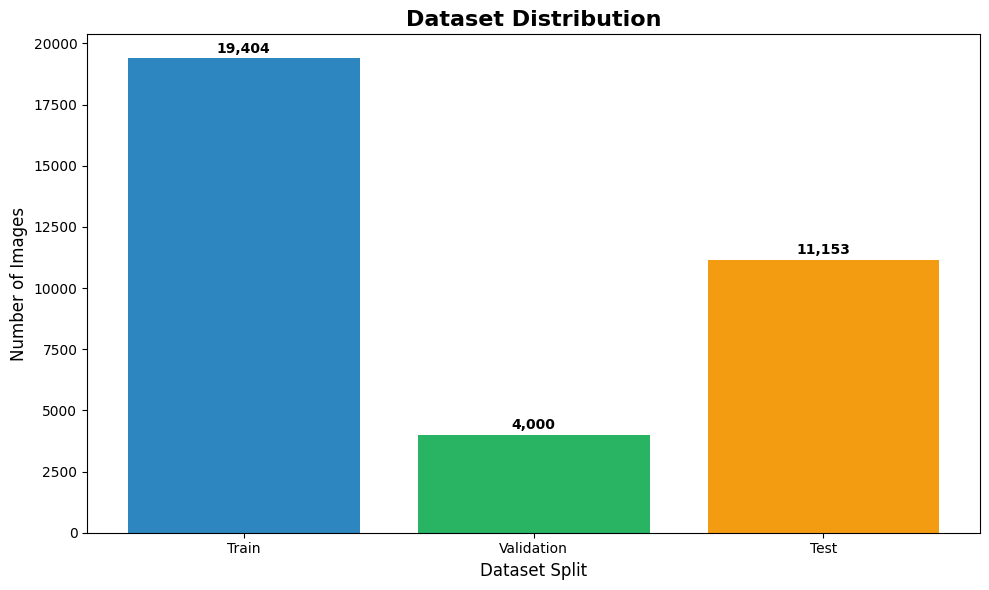

In [4]:
# Analyze dataset distribution
def count_files_in_directory(directory):
    """Count files in a directory"""
    return len([f for f in os.listdir(directory) if f.endswith(('.jpg', '.jpeg', '.png'))])

# Count images in each split
train_images = count_files_in_directory(DATASET_PATH / "images" / "train")
val_images = count_files_in_directory(DATASET_PATH / "images" / "val")
test_images = count_files_in_directory(DATASET_PATH / "images" / "test")

print(f"Training images: {train_images:,}")
print(f"Validation images: {val_images:,}")
print(f"Test images: {test_images:,}")
print(f"Total images: {train_images + val_images + test_images:,}")

# Visualize dataset distribution
plt.figure(figsize=(10, 6))
splits = ['Train', 'Validation', 'Test']
counts = [train_images, val_images, test_images]

plt.bar(splits, counts, color=['#2E86C1', '#28B463', '#F39C12'])
plt.title('Dataset Distribution', fontsize=16, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Dataset Split', fontsize=12)

# Add value labels on bars
for i, v in enumerate(counts):
    plt.text(i, v + 100, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
# Analyze class distribution in training labels
def analyze_label_distribution(labels_dir):
    """Analyze class distribution in YOLO format labels"""
    class_counts = Counter()
    total_objects = 0
    
    for label_file in os.listdir(labels_dir):
        if label_file.endswith('.txt'):
            with open(os.path.join(labels_dir, label_file), 'r') as f:
                lines = f.readlines()
                for line in lines:
                    if line.strip():
                        class_id = int(line.split()[0])
                        class_counts[class_id] += 1
                        total_objects += 1
    
    return class_counts, total_objects

# Analyze training set
train_labels_dir = DATASET_PATH / "labels" / "train"
class_counts, total_objects = analyze_label_distribution(train_labels_dir)

print(f"Total objects in training set: {total_objects:,}")
print(f"Average objects per image: {total_objects/train_images:.2f}")

# Create class distribution visualization
class_names = dataset_config['names']
class_data = []

for class_id, class_name in enumerate(class_names):
    count = class_counts.get(class_id, 0)
    percentage = (count / total_objects) * 100 if total_objects > 0 else 0
    class_data.append({'Class': class_name, 'Count': count, 'Percentage': percentage})

df_classes = pd.DataFrame(class_data)
df_classes = df_classes.sort_values('Count', ascending=False)

print("\nClass Distribution:")
print(df_classes.to_string(index=False))

Total objects in training set: 116,945
Average objects per image: 6.03

Class Distribution:
         Class  Count  Percentage
        Worker  77770   66.501347
     Excavator   9435    8.067895
  Static crane   7560    6.464577
 Other vehicle   5130    4.386677
         Truck   5007    4.281500
  Hanging head   2734    2.337851
         Crane   2629    2.248065
Concrete mixer   1508    1.289495
    Pump truck   1443    1.233913
  Pile driving   1051    0.898713
     Bulldozer    961    0.821754
        Loader    873    0.746505
        Roller    844    0.721707


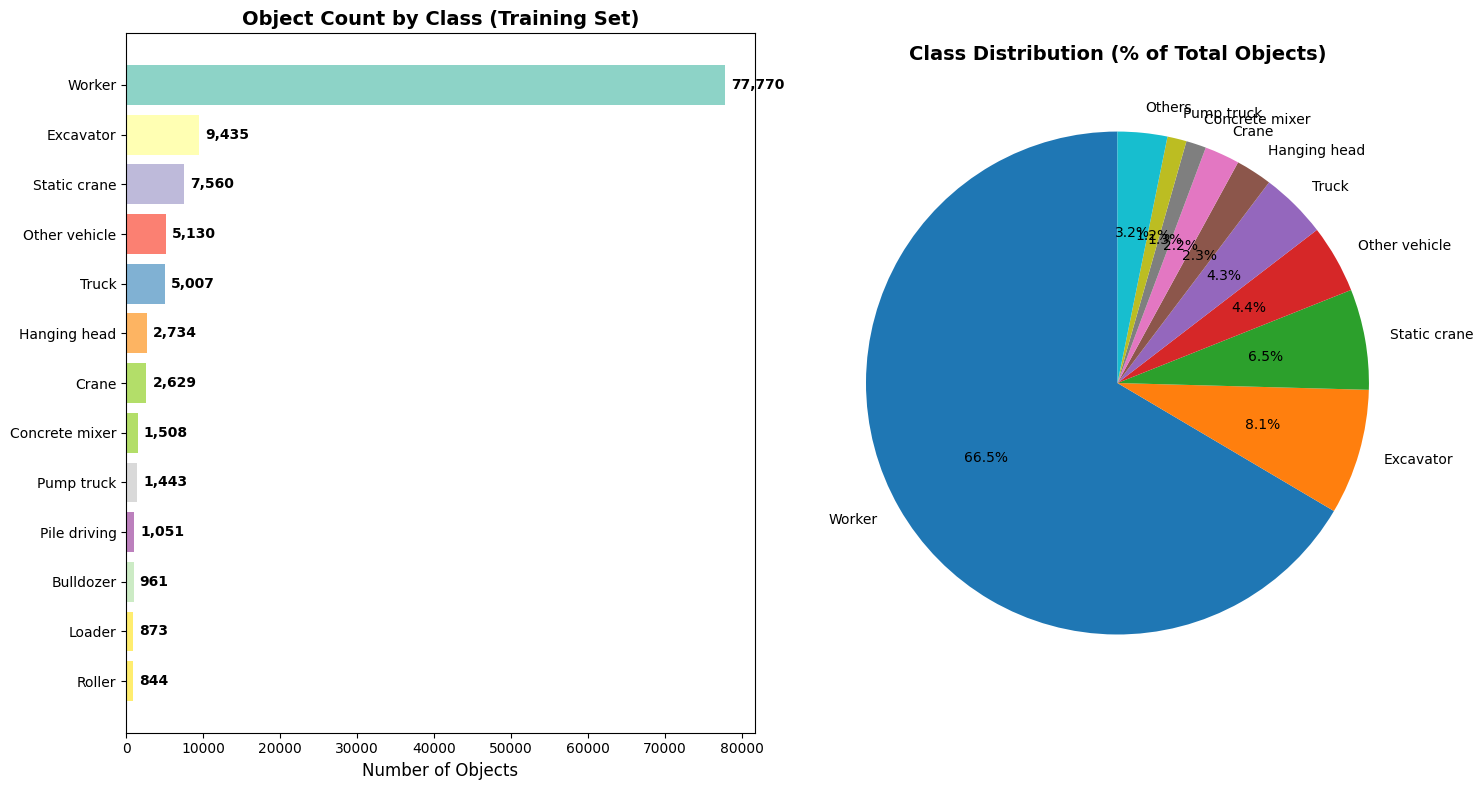

In [6]:
# Visualize class distribution
plt.figure(figsize=(15, 8))

# Create a horizontal bar plot
plt.subplot(1, 2, 1)
colors = plt.cm.Set3(np.linspace(0, 1, len(df_classes)))
bars = plt.barh(df_classes['Class'], df_classes['Count'], color=colors)
plt.title('Object Count by Class (Training Set)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Objects', fontsize=12)
plt.gca().invert_yaxis()

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, df_classes['Count'])):
    plt.text(bar.get_width() + max(df_classes['Count']) * 0.01, bar.get_y() + bar.get_height()/2, 
             f'{count:,}', ha='left', va='center', fontweight='bold')

# Create a pie chart for percentage distribution
plt.subplot(1, 2, 2)
# Only show classes with significant representation
threshold = 1.0  # Show classes with at least 1% representation
significant_classes = df_classes[df_classes['Percentage'] >= threshold]
other_percentage = df_classes[df_classes['Percentage'] < threshold]['Percentage'].sum()

if other_percentage > 0:
    pie_data = list(significant_classes['Percentage']) + [other_percentage]
    pie_labels = list(significant_classes['Class']) + ['Others']
else:
    pie_data = significant_classes['Percentage']
    pie_labels = significant_classes['Class']

plt.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution (% of Total Objects)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Sample Data Visualization

Training Set Samples:


Training Set Samples:


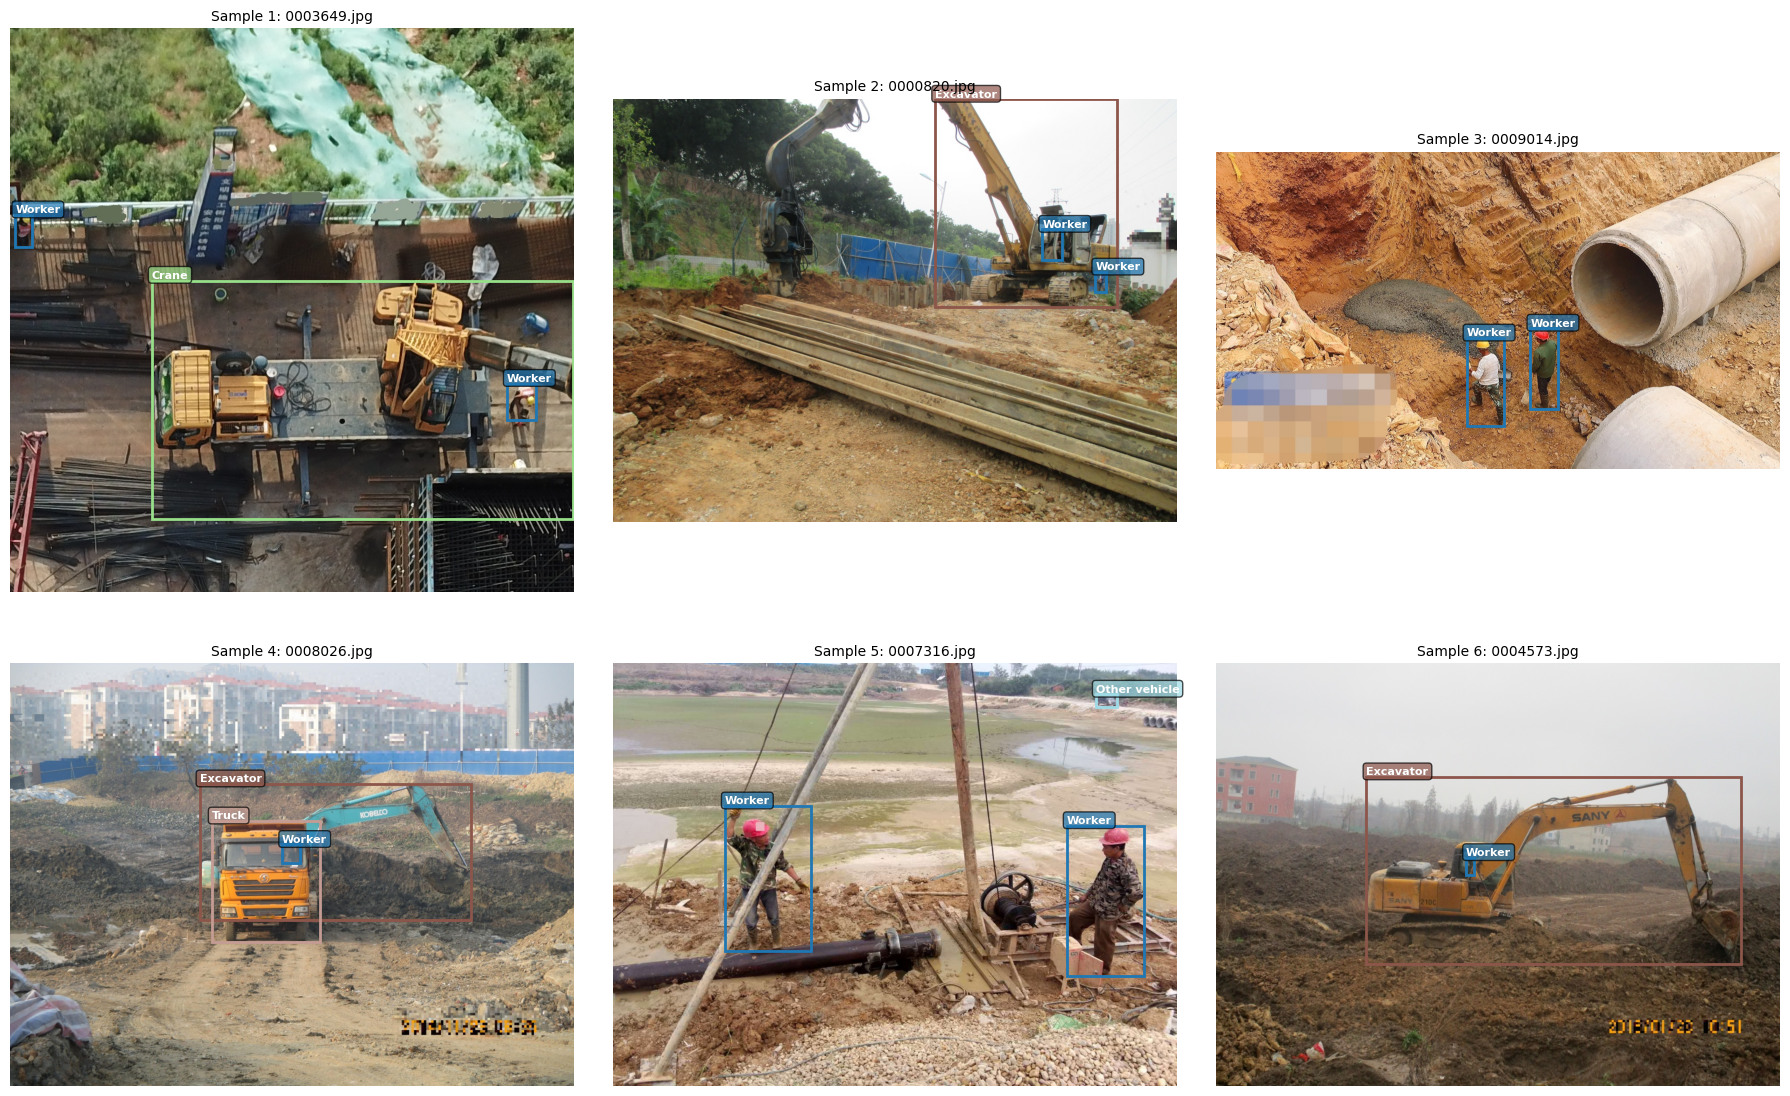

In [7]:
# Visualize sample images with annotations
def visualize_sample_images(images_dir, labels_dir, class_names, num_samples=6):
    """Visualize sample images with their bounding box annotations"""
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
    
    for idx, image_file in enumerate(sample_files):
        # Load image
        img_path = os.path.join(images_dir, image_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Load corresponding label
        label_file = image_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        
        ax = axes[idx]
        ax.imshow(image)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                if line.strip():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    # Convert YOLO format to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    # Draw bounding box
                    rect = plt.Rectangle((x1, y1), width, height, fill=False, 
                                       color=colors[class_id], linewidth=2)
                    ax.add_patch(rect)
                    
                    # Add class label
                    ax.text(x1, y1-5, class_names[class_id], 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[class_id], alpha=0.7),
                           fontsize=8, color='white', fontweight='bold')
        
        ax.set_title(f'Sample {idx+1}: {image_file}', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize training samples
print("Training Set Samples:")
visualize_sample_images(
    DATASET_PATH / "images" / "train",
    DATASET_PATH / "labels" / "train",
    class_names
)

## 5. Model Configuration and Training Setup

In [8]:
# Training configuration
TRAIN_CONFIG = {
    'model_size': 'yolov8n',  # Options: yolov8n, yolov8s, yolov8m, yolov8l, yolov8x
    'epochs': 100,
    'batch_size': 16,
    'img_size': 640,
    'patience': 20,
    'save_period': 10,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'workers': 4,
    'optimizer': 'AdamW',
    'lr0': 0.01,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'box': 7.5,
    'cls': 0.5,
    'dfl': 1.5,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.0,
    'copy_paste': 0.0
}

print("Training Configuration:")
for key, value in TRAIN_CONFIG.items():
    print(f"{key}: {value}")

# Adjust batch size based on available GPU memory
if torch.cuda.is_available():
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    if gpu_memory_gb < 8:
        TRAIN_CONFIG['batch_size'] = 8
        print(f"\nAdjusted batch size to {TRAIN_CONFIG['batch_size']} due to limited GPU memory ({gpu_memory_gb:.1f} GB)")
    elif gpu_memory_gb >= 24:
        TRAIN_CONFIG['batch_size'] = 32
        print(f"\nIncreased batch size to {TRAIN_CONFIG['batch_size']} due to sufficient GPU memory ({gpu_memory_gb:.1f} GB)")

Training Configuration:
model_size: yolov8n
epochs: 100
batch_size: 16
img_size: 640
patience: 20
save_period: 10
device: cuda
workers: 4
optimizer: AdamW
lr0: 0.01
weight_decay: 0.0005
warmup_epochs: 3
box: 7.5
cls: 0.5
dfl: 1.5
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 0.0
translate: 0.1
scale: 0.5
shear: 0.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
mosaic: 1.0
mixup: 0.0
copy_paste: 0.0

Adjusted batch size to 8 due to limited GPU memory (4.0 GB)


## 6. Model Training

In [9]:
# Initialize the model
model = YOLO(f"{TRAIN_CONFIG['model_size']}.pt")  # Load pretrained model

# Display model information
print(f"Model: {TRAIN_CONFIG['model_size']}")
print(f"Device: {TRAIN_CONFIG['device']}")
print(f"Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

# Create training arguments
train_args = {
    'data': str(YAML_PATH),
    'epochs': TRAIN_CONFIG['epochs'],
    'batch': TRAIN_CONFIG['batch_size'],
    'imgsz': TRAIN_CONFIG['img_size'],
    'device': TRAIN_CONFIG['device'],
    'workers': TRAIN_CONFIG['workers'],
    'patience': TRAIN_CONFIG['patience'],
    'save_period': TRAIN_CONFIG['save_period'],
    'optimizer': TRAIN_CONFIG['optimizer'],
    'lr0': TRAIN_CONFIG['lr0'],
    'weight_decay': TRAIN_CONFIG['weight_decay'],
    'warmup_epochs': TRAIN_CONFIG['warmup_epochs'],
    'box': TRAIN_CONFIG['box'],
    'cls': TRAIN_CONFIG['cls'],
    'dfl': TRAIN_CONFIG['dfl'],
    'hsv_h': TRAIN_CONFIG['hsv_h'],
    'hsv_s': TRAIN_CONFIG['hsv_s'],
    'hsv_v': TRAIN_CONFIG['hsv_v'],
    'degrees': TRAIN_CONFIG['degrees'],
    'translate': TRAIN_CONFIG['translate'],
    'scale': TRAIN_CONFIG['scale'],
    'shear': TRAIN_CONFIG['shear'],
    'perspective': TRAIN_CONFIG['perspective'],
    'flipud': TRAIN_CONFIG['flipud'],
    'fliplr': TRAIN_CONFIG['fliplr'],
    'mosaic': TRAIN_CONFIG['mosaic'],
    'mixup': TRAIN_CONFIG['mixup'],
    'copy_paste': TRAIN_CONFIG['copy_paste'],
    'project': 'runs/detect',
    'name': f'mocs_{TRAIN_CONFIG["model_size"]}_train',
    'exist_ok': True,
    'pretrained': True,
    'verbose': True
}

print("\nStarting training...")
print(f"Training will run for up to {TRAIN_CONFIG['epochs']} epochs with early stopping patience of {TRAIN_CONFIG['patience']}")
print(f"Results will be saved to: runs/detect/mocs_{TRAIN_CONFIG['model_size']}_train")
print("\n" + "="*50)

Model: yolov8n
Device: cuda
Parameters: 3,157,200

Starting training...
Training will run for up to 100 epochs with early stopping patience of 20
Results will be saved to: runs/detect/mocs_yolov8n_train

Model: yolov8n
Device: cuda
Parameters: 3,157,200

Starting training...
Training will run for up to 100 epochs with early stopping patience of 20
Results will be saved to: runs/detect/mocs_yolov8n_train



In [ ]:
# Train the model
results = model.train(**train_args)

print("\nTraining completed!")
print(f"Best model saved to: {model.trainer.best}")
print(f"Last model saved to: {model.trainer.last}")

# Get the best model path
best_model_path = model.trainer.best
print(f"\nBest model path: {best_model_path}")

Ultralytics 8.3.202  Python-3.13.7 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mocs_yolov8n_train, nbs=64, nms=False, opset=None, opt

## 7. Training Results Analysis

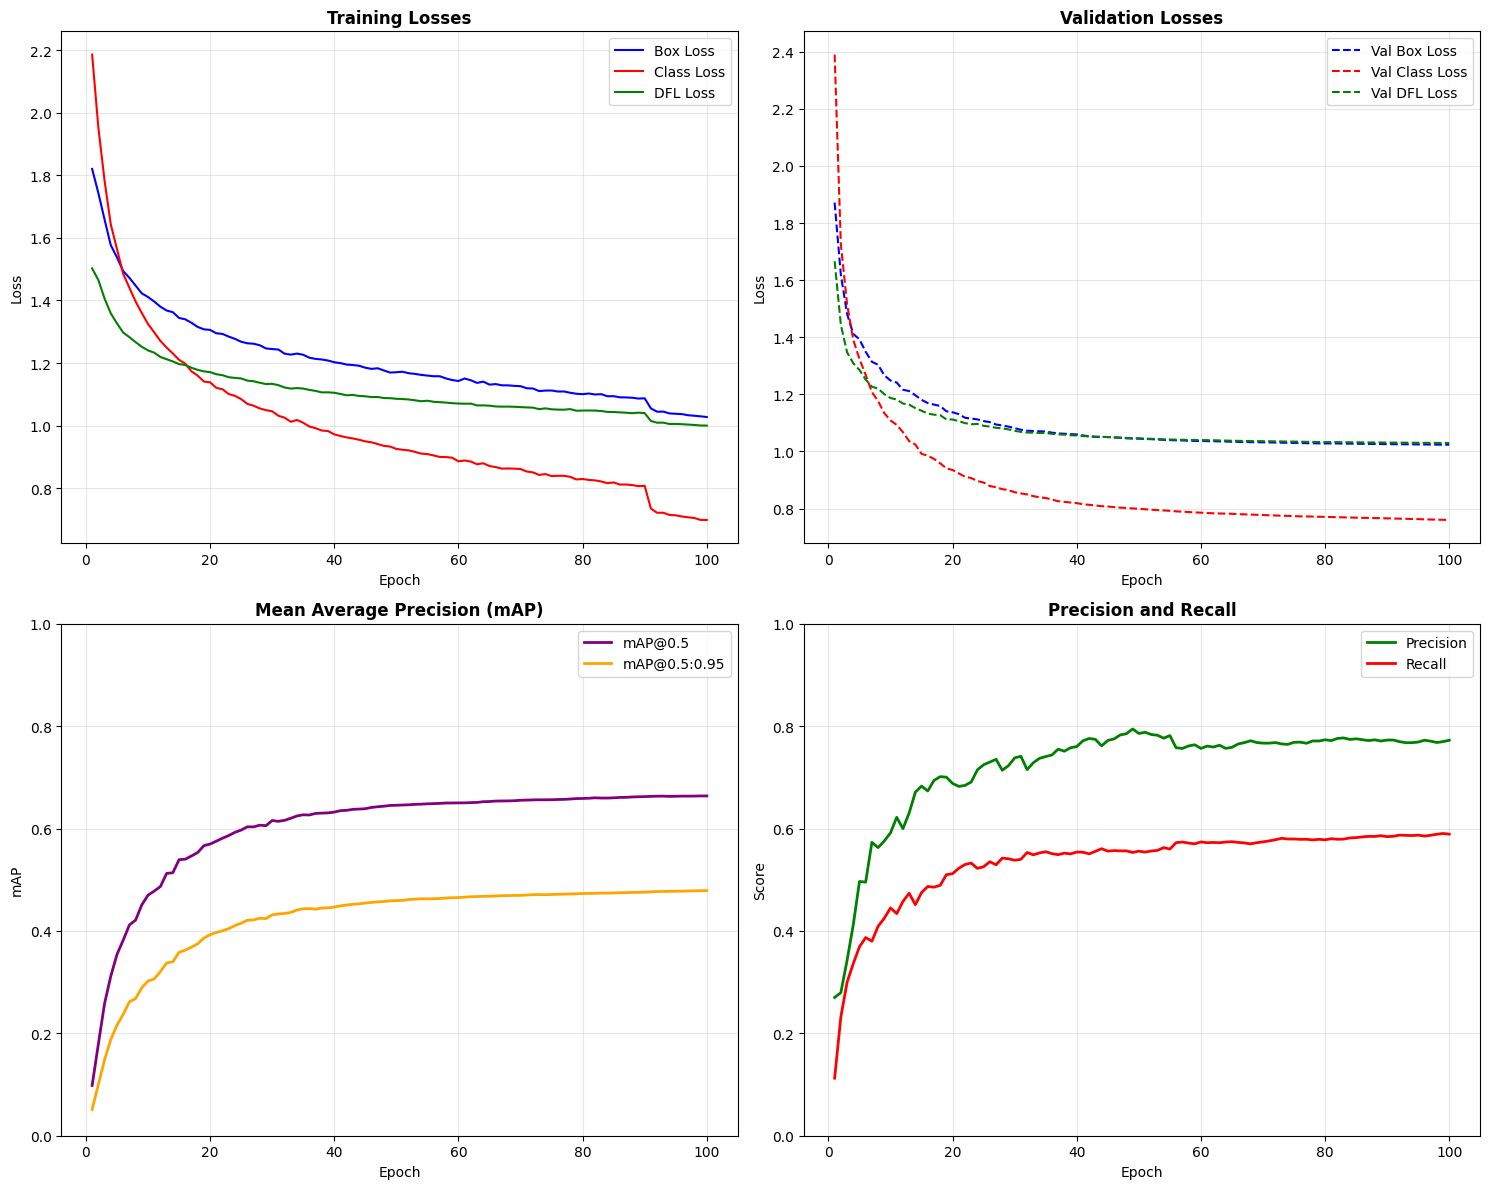

Final Training Metrics:
Epoch: 100
mAP@0.5: 0.6638
mAP@0.5:0.95: 0.4789
Precision: 0.7726
Recall: 0.5891


In [15]:
# Load and display training result
from ultralytics.utils.plotting import plot_results

# Get the results directory
results_dir = Path(f"runs/detect/mocs_{TRAIN_CONFIG['model_size']}_train")

# Plot training results
if (results_dir / "results.csv").exists():
    # Read training results
    results_df = pd.read_csv(results_dir / "results.csv")
    results_df.columns = results_df.columns.str.strip()  # Remove any whitespace
    
    # Create training plots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Loss plots
    axes[0, 0].plot(results_df['epoch'], results_df['train/box_loss'], label='Box Loss', color='blue')
    axes[0, 0].plot(results_df['epoch'], results_df['train/cls_loss'], label='Class Loss', color='red')
    axes[0, 0].plot(results_df['epoch'], results_df['train/dfl_loss'], label='DFL Loss', color='green')
    axes[0, 0].set_title('Training Losses', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Validation metrics
    if 'val/box_loss' in results_df.columns:
        axes[0, 1].plot(results_df['epoch'], results_df['val/box_loss'], label='Val Box Loss', color='blue', linestyle='--')
        axes[0, 1].plot(results_df['epoch'], results_df['val/cls_loss'], label='Val Class Loss', color='red', linestyle='--')
        axes[0, 1].plot(results_df['epoch'], results_df['val/dfl_loss'], label='Val DFL Loss', color='green', linestyle='--')
        axes[0, 1].set_title('Validation Losses', fontweight='bold')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
    
    # mAP metrics
    if 'metrics/mAP50(B)' in results_df.columns:
        axes[1, 0].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@0.5', color='purple', linewidth=2)
        axes[1, 0].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='orange', linewidth=2)
        axes[1, 0].set_title('Mean Average Precision (mAP)', fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('mAP')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim(0, 1)
    
    # Precision and Recall
    if 'metrics/precision(B)' in results_df.columns:
        axes[1, 1].plot(results_df['epoch'], results_df['metrics/precision(B)'], label='Precision', color='green', linewidth=2)
        axes[1, 1].plot(results_df['epoch'], results_df['metrics/recall(B)'], label='Recall', color='red', linewidth=2)
        axes[1, 1].set_title('Precision and Recall', fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Score')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    final_epoch = results_df.iloc[-1]
    print("Final Training Metrics:")
    print(f"Epoch: {final_epoch['epoch']:.0f}")
    if 'metrics/mAP50(B)' in results_df.columns:
        print(f"mAP@0.5: {final_epoch['metrics/mAP50(B)']:.4f}")
        print(f"mAP@0.5:0.95: {final_epoch['metrics/mAP50-95(B)']:.4f}")
    if 'metrics/precision(B)' in results_df.columns:
        print(f"Precision: {final_epoch['metrics/precision(B)']:.4f}")
        print(f"Recall: {final_epoch['metrics/recall(B)']:.4f}")

else:
    print("Results file not found. Training may not have completed successfully.")

## 8. Model Evaluation

In [16]:
# Load the best trained model for evaluation
best_model = YOLO(best_model_path)

# Evaluate on validation set
print("Evaluating model on validation set...")
val_results = best_model.val(data=str(YAML_PATH), split='val', save_json=True)

# Display validation results
print("\nValidation Results:")
print(f"mAP@0.5: {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision: {val_results.box.mp:.4f}")
print(f"Recall: {val_results.box.mr:.4f}")
print(f"F1-Score: {2 * (val_results.box.mp * val_results.box.mr) / (val_results.box.mp + val_results.box.mr):.4f}")

Evaluating model on validation set...
Ultralytics 8.3.202  Python-3.13.7 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 303.7182.2 MB/s, size: 337.3 KB)
val: Scanning D:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\labels\val.cache... 4000 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4000/4000 3.5Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 250/250 5.4it/s 46.1s<0.1s
                   all       4000      18965      0.774       0.59      0.665      0.479
                Worker       3091      11658      0.883      0.668      0.774      0.503
          Static crane        434        972      0.792      0.625      0.706      0.502
          Hanging head        243        307      0.789      0.329      0.409      0.216
      

In [18]:
# Evaluate on test set
print("Evaluating model on test set...")
test_results = best_model.val(data=str(YAML_PATH), split='test', save_json=True)

# Display test results
print("\nTest Results:")
print(f"mAP@0.5: {test_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall: {test_results.box.mr:.4f}")
print(f"F1-Score: {2 * (test_results.box.mp * test_results.box.mr) / (test_results.box.mp + test_results.box.mr):.4f}")

# Per-class metrics
if hasattr(test_results.box, 'maps'):
    print("\nPer-class mAP@0.5:")
    for i, (class_name, map_score) in enumerate(zip(class_names, test_results.box.maps)):
        print(f"{class_name}: {map_score:.4f}")

Evaluating model on test set...
Ultralytics 8.3.202  Python-3.13.7 torch-2.8.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 282.466.3 MB/s, size: 392.3 KB)
val: Scanning D:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\labels\test.cache... 0 images, 18264 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 18264/18264 12.9Mit/s 0.0ss
WARNING Labels are missing or empty in D:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\labels\test.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1142/1142 6.7it/s 2:51<0.1s


d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\ultralytics\utils\metrics.py:668: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\ultralytics\utils\metrics.py:713: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\ultralytics\utils\metrics.py:713: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
d:\Projects\UrbanNoiseClassifier\.venv\Lib\site-packages\numpy\_core\_methods.py:137: RuntimeWarning: inval

                   all      18264          0          0          0          0          0
WARNING no labels found in detect set, can not compute metrics without labels
Speed: 0.2ms preprocess, 3.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Saving D:\Projects\UrbanNoiseClassifier\project\image-classifier\YOLOv8\runs\detect\val6\predictions.json...
Results saved to D:\Projects\UrbanNoiseClassifier\project\image-classifier\YOLOv8\runs\detect\val6

Test Results:
mAP@0.5: 0.0000
mAP@0.5:0.95: 0.0000
Precision: 0.0000
Recall: 0.0000


ZeroDivisionError: float division by zero

## 9. Inference and Visualization

Model predictions on test images (confidence threshold: 0.5):

image 1/1 d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\images\test\0030108.jpg: 480x640 1 Worker, 2 Excavators, 120.7ms
Speed: 8.6ms preprocess, 120.7ms inference, 9.0ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\images\test\0041514.jpg: 640x480 1 Pile driving, 82.8ms
Speed: 7.3ms preprocess, 82.8ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\images\test\0039039.jpg: 480x640 12 Workers, 44.3ms
Speed: 6.0ms preprocess, 44.3ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 d:\Projects\UrbanNoiseClassifier\project\image-classifier\data\MOCS\yolo_dataset\images\test\0037915.jpg: 480x640 1 Worker, 1 Roller, 42.8ms
Speed: 4.6ms preprocess, 42.8ms inference, 2.

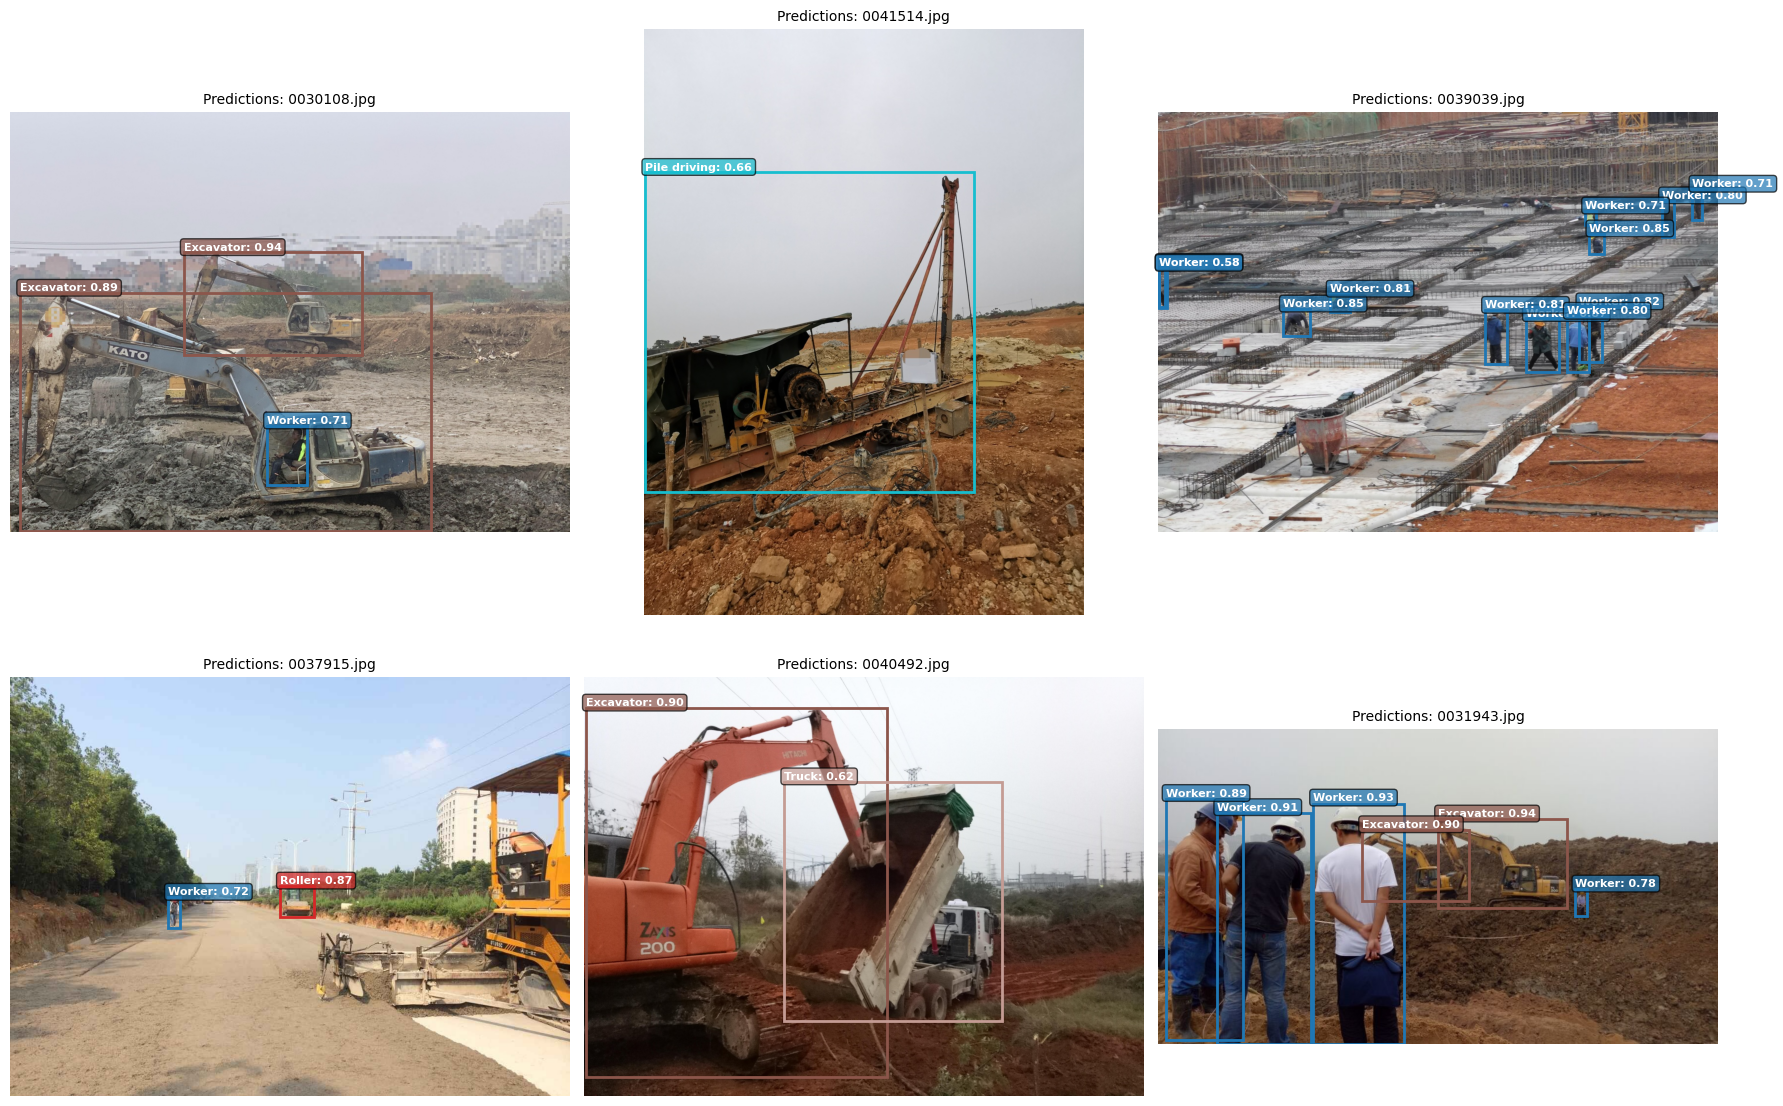

In [19]:
# Perform inference on sample test images
def visualize_predictions(model, images_dir, class_names, num_samples=6, conf_threshold=0.5):
    """Visualize model predictions on sample images"""
    image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    sample_files = random.sample(image_files, min(num_samples, len(image_files)))
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    colors = plt.cm.tab20(np.linspace(0, 1, len(class_names)))
    
    for idx, image_file in enumerate(sample_files):
        img_path = os.path.join(images_dir, image_file)
        
        # Run inference
        results = model(img_path, conf=conf_threshold)
        
        # Load and display image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        ax = axes[idx]
        ax.imshow(image)
        
        # Draw predictions
        for result in results:
            boxes = result.boxes
            if boxes is not None:
                for box in boxes:
                    # Get box coordinates
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                    conf = box.conf[0].cpu().numpy()
                    cls = int(box.cls[0].cpu().numpy())
                    
                    # Draw bounding box
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, 
                                       color=colors[cls], linewidth=2)
                    ax.add_patch(rect)
                    
                    # Add label with confidence
                    label = f"{class_names[cls]}: {conf:.2f}"
                    ax.text(x1, y1-5, label, 
                           bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[cls], alpha=0.7),
                           fontsize=8, color='white', fontweight='bold')
        
        ax.set_title(f'Predictions: {image_file}', fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize predictions on test set
print(f"Model predictions on test images (confidence threshold: 0.5):")
visualize_predictions(
    best_model,
    DATASET_PATH / "images" / "test",
    class_names,
    num_samples=6,
    conf_threshold=0.5
)

## 10. Model Export and Deployment

In [20]:
# Export model to different formats
print("Exporting model to different formats...")

# Export to ONNX format
try:
    onnx_path = best_model.export(format='onnx')
    print(f"ONNX model exported to: {onnx_path}")
except Exception as e:
    print(f"ONNX export failed: {e}")

# Export to TorchScript
try:
    torchscript_path = best_model.export(format='torchscript')
    print(f"TorchScript model exported to: {torchscript_path}")
except Exception as e:
    print(f"TorchScript export failed: {e}")

# Export to TensorFlow Lite (if needed)
# Uncomment if you need TFLite format
# try:
#     tflite_path = best_model.export(format='tflite')
#     print(f"TensorFlow Lite model exported to: {tflite_path}")
# except Exception as e:
#     print(f"TensorFlow Lite export failed: {e}")

Exporting model to different formats...
Ultralytics 8.3.202  Python-3.13.7 torch-2.8.0+cu126 CPU (AMD Ryzen 7 6800H with Radeon Graphics)

PyTorch: starting from 'D:\Projects\UrbanNoiseClassifier\project\image-classifier\YOLOv8\runs\detect\mocs_yolov8n_train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 17, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.67', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 1.3 MB/s eta 0:00:13
   - -------------------------------------- 0.5/16.5 MB 1.3 MB/s eta 0:00:13
   - -------------------------------------- 0.8/16.5 MB 1.3 MB/s eta 0:00:13
   -- ------------------------------------- 1.0/16.5 MB 1.2 MB/s eta 0:00:13
   --- ------------------------------------ 1.3/16.5 MB 1.2 MB/

## 11. Performance Benchmarking

Benchmarking model performance on 100 test images...

Performance Metrics:
Average inference time: 32.22 ms
FPS (single image): 31.04
Throughput (batch): 31.00 images/second
Total detections: 402
Average detections per image: 4.02


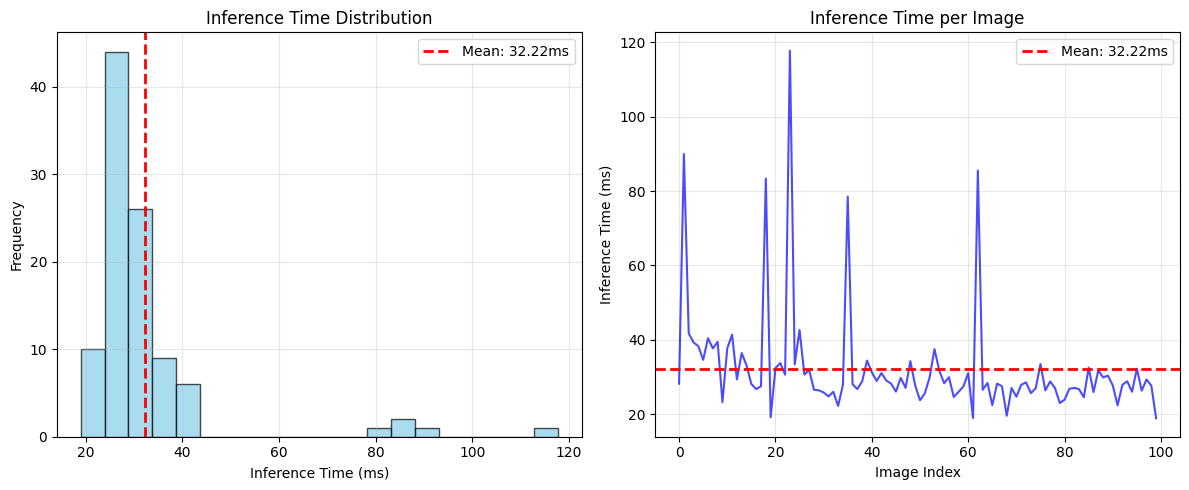

In [21]:
# Benchmark model performance
import time

# Prepare test images for benchmarking
test_images_dir = DATASET_PATH / "images" / "test"
test_image_files = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
benchmark_images = random.sample(test_image_files, min(100, len(test_image_files)))

print(f"Benchmarking model performance on {len(benchmark_images)} test images...")

# Warmup
warmup_image = os.path.join(test_images_dir, benchmark_images[0])
for _ in range(10):
    _ = best_model(warmup_image, verbose=False)

# Benchmark inference time
inference_times = []
total_detections = 0

start_time = time.time()
for img_file in benchmark_images:
    img_path = os.path.join(test_images_dir, img_file)
    
    img_start = time.time()
    results = best_model(img_path, verbose=False)
    img_end = time.time()
    
    inference_times.append(img_end - img_start)
    
    # Count detections
    for result in results:
        if result.boxes is not None:
            total_detections += len(result.boxes)

total_time = time.time() - start_time

# Calculate statistics
avg_inference_time = np.mean(inference_times) * 1000  # Convert to ms
fps = 1 / np.mean(inference_times)
throughput = len(benchmark_images) / total_time

print("\nPerformance Metrics:")
print(f"Average inference time: {avg_inference_time:.2f} ms")
print(f"FPS (single image): {fps:.2f}")
print(f"Throughput (batch): {throughput:.2f} images/second")
print(f"Total detections: {total_detections}")
print(f"Average detections per image: {total_detections/len(benchmark_images):.2f}")

# Visualize inference time distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(np.array(inference_times) * 1000, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(avg_inference_time, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_inference_time:.2f}ms')
plt.xlabel('Inference Time (ms)')
plt.ylabel('Frequency')
plt.title('Inference Time Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(len(inference_times)), np.array(inference_times) * 1000, 'b-', alpha=0.7)
plt.axhline(avg_inference_time, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_inference_time:.2f}ms')
plt.xlabel('Image Index')
plt.ylabel('Inference Time (ms)')
plt.title('Inference Time per Image')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Summary and Recommendations

In [22]:
# Create a comprehensive summary
print("=" * 60)
print("YOLOV8 TRAINING SUMMARY")
print("=" * 60)

print(f"\nDataset: MOCS Construction Object Detection")
print(f"Model: {TRAIN_CONFIG['model_size'].upper()}")
print(f"Classes: {len(class_names)}")
print(f"Training Images: {train_images:,}")
print(f"Validation Images: {val_images:,}")
print(f"Test Images: {test_images:,}")

print(f"\nTraining Configuration:")
print(f"Epochs: {TRAIN_CONFIG['epochs']}")
print(f"Batch Size: {TRAIN_CONFIG['batch_size']}")
print(f"Image Size: {TRAIN_CONFIG['img_size']}")
print(f"Device: {TRAIN_CONFIG['device']}")

if 'test_results' in locals():
    print(f"\nFinal Test Results:")
    print(f"mAP@0.5: {test_results.box.map50:.4f}")
    print(f"mAP@0.5:0.95: {test_results.box.map:.4f}")
    print(f"Precision: {test_results.box.mp:.4f}")
    print(f"Recall: {test_results.box.mr:.4f}")

if 'avg_inference_time' in locals():
    print(f"\nPerformance:")
    print(f"Average Inference Time: {avg_inference_time:.2f} ms")
    print(f"FPS: {fps:.2f}")

print(f"\nModel Files:")
print(f"Best Model: {best_model_path}")
print(f"Results Directory: runs/detect/mocs_{TRAIN_CONFIG['model_size']}_train")

print("\n" + "=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

print("\n1. Model Performance:")
if 'test_results' in locals():
    if test_results.box.map50 > 0.8:
        print("   ✓ Excellent performance! The model achieves high mAP@0.5")
    elif test_results.box.map50 > 0.6:
        print("   ✓ Good performance. Consider fine-tuning for better results")
    else:
        print("   ⚠ Performance could be improved. Consider:")
        print("     - Increasing training epochs")
        print("     - Using a larger model variant (e.g., yolov8m or yolov8l)")
        print("     - Adjusting data augmentation parameters")
        print("     - Collecting more training data")

print("\n2. Inference Speed:")
if 'avg_inference_time' in locals():
    if avg_inference_time < 50:
        print("   ✓ Fast inference suitable for real-time applications")
    elif avg_inference_time < 100:
        print("   ✓ Good inference speed for most applications")
    else:
        print("   ⚠ Consider optimizing for faster inference:")
        print("     - Use model quantization")
        print("     - Export to optimized formats (TensorRT, ONNX)")
        print("     - Use smaller model variant")

print("\n3. Next Steps:")
print("   - Test the model on real-world construction site images")
print("   - Implement post-processing for specific use cases")
print("   - Consider ensemble methods for improved accuracy")
print("   - Deploy using appropriate inference framework")
print("   - Monitor model performance on new data")

print("\n4. Files Generated:")
print(f"   - Trained model weights: {best_model_path}")
print(f"   - Training logs and metrics: runs/detect/mocs_{TRAIN_CONFIG['model_size']}_train/")
print("   - Exported models (ONNX, TorchScript) in the same directory")

print("\n" + "=" * 60)

YOLOV8 TRAINING SUMMARY

Dataset: MOCS Construction Object Detection
Model: YOLOV8N
Classes: 13
Training Images: 19,404
Validation Images: 4,000
Test Images: 11,153

Training Configuration:
Epochs: 100
Batch Size: 8
Image Size: 640
Device: cuda

Final Test Results:
mAP@0.5: 0.0000
mAP@0.5:0.95: 0.0000
Precision: 0.0000
Recall: 0.0000

Performance:
Average Inference Time: 32.22 ms
FPS: 31.04

Model Files:
Best Model: D:\Projects\UrbanNoiseClassifier\project\image-classifier\YOLOv8\runs\detect\mocs_yolov8n_train\weights\best.pt
Results Directory: runs/detect/mocs_yolov8n_train

RECOMMENDATIONS

1. Model Performance:
   ⚠ Performance could be improved. Consider:
     - Increasing training epochs
     - Using a larger model variant (e.g., yolov8m or yolov8l)
     - Adjusting data augmentation parameters
     - Collecting more training data

2. Inference Speed:
   ✓ Fast inference suitable for real-time applications

3. Next Steps:
   - Test the model on real-world construction site images
